# TSP lookback volatility targeting with optional high-volatility adjustment

This notebook is based on the TSP lookback and volatility-targeting strategy. It optionally reduces a fund's allocation when its current volatility rises to or above a configurable fraction of its own rolling volatility reference. The adjustment is disabled by default.

In [129]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')

## Configuration

Set `HIGH_VOL_ADJUSTMENT_ENABLED = True` to activate the high-volatility feature. When a fund's current volatility is at or above `HIGH_VOL_THRESHOLD` times its rolling reference volatility, its allocation is multiplied by `HIGH_VOL_WEIGHT_MULTIPLIER`. The removed allocation is redistributed to other non-penalized funds, or to G Fund when no other destination is available.

In [140]:
DATA_URL = 'https://www.tsp.gov/data/fund-price-history.csv'
if Path('portfolio/data').exists():
    DATA_DIR = Path('portfolio/data')
elif Path('../../portfolio/data').exists():
    DATA_DIR = Path('../../portfolio/data')
else:
    DATA_DIR = Path('data')
CACHE_PATH = DATA_DIR / 'fund-price-history.csv'
START_DATE = None  # e.g. '2010-01-01'; None uses all available common history
RISK_FREE_RATE = 0.02
TRADING_DAYS = 252
BENCHMARK_TICKER = 'SPY'

# Optimizer inputs; G Fund remains fallback-only. Zero weights disable funds.
MANUAL_WEIGHTS = {
    'F Fund': 0.00,
    'C Fund': 1.00,
    'S Fund': 0.00,
    'I Fund': 0.00,
}
LOOKBACKS = {
    'F Fund': 80,
    'C Fund': 150,
    'S Fund': 100,
    'I Fund': 80,
}
FALLBACK_FUND = 'G Fund'

# Independent passive comparison portfolio.
PASSIVE_WEIGHTS = {
    'G Fund': 0.34,
    'C Fund': 0.66,
}

VOL_LOOKBACK = 40
TARGET_ANNUAL_VOL = 0.2
VOLATILITY_POWER = 1.0
MAX_WEIGHT = 1.00
REBALANCE_FREQUENCY = 'M'
MAX_GROSS_EXPOSURE = 1.00

# Optional high-volatility allocation adjustment.
HIGH_VOL_ADJUSTMENT_ENABLED = True
HIGH_VOL_THRESHOLD = 1.20  # current vol >= 50% of reference vol
HIGH_VOL_WEIGHT_MULTIPLIER = 0.70  # multiply the fund's allocation by 50%
HIGH_VOL_REFERENCE_LOOKBACK = 252  # rolling median volatility reference

## Load TSP prices and benchmark

In [141]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
if not CACHE_PATH.exists():
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/131.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/csv,text/plain;q=0.9,*/*;q=0.8',
        'Referer': 'https://www.tsp.gov/',
    }
    response = requests.get(DATA_URL, headers=headers, timeout=30)
    response.raise_for_status()
    CACHE_PATH.write_bytes(response.content)
    print(f'Downloaded {len(response.content):,} bytes to {CACHE_PATH}')
else:
    print(f'Using cached file: {CACHE_PATH}')

raw = pd.read_csv(CACHE_PATH)
date_candidates = [
    column for column in raw.columns
    if str(column).strip().lower() in {'date', 'as of date', 'price date'}
]
date_column = date_candidates[0] if date_candidates else raw.columns[0]
raw[date_column] = pd.to_datetime(raw[date_column], errors='coerce')
prices = raw.set_index(date_column).sort_index()
prices = prices.apply(
    lambda series: pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False), errors='coerce'
    )
)
prices = prices.loc[:, prices.notna().sum() >= 20].dropna(how='all')
prices = prices[~prices.index.duplicated(keep='last')]

benchmark_data = yf.download(
    BENCHMARK_TICKER,
    start=prices.index.min(),
    end=prices.index.max() + pd.Timedelta(days=1),
    auto_adjust=False,
    progress=False,
)
benchmark_prices = benchmark_data['Adj Close']
if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]
benchmark_prices = pd.to_numeric(benchmark_prices, errors='coerce').sort_index().dropna()
if benchmark_prices.empty:
    raise ValueError(f'No benchmark data returned for {BENCHMARK_TICKER}.')
print(f'TSP data range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Benchmark: {BENCHMARK_TICKER}')

Using cached file: ../../portfolio/data/fund-price-history.csv
TSP data range: 2003-05-31 to 2026-08-21
Benchmark: SPY


## Build signals, adjusted weights, and volatility-targeted returns

In [142]:
weights = pd.Series(MANUAL_WEIGHTS, dtype=float)
weights.index = weights.index.map(str).str.strip()
weights = weights.groupby(level=0).sum()
if weights.empty or not np.isfinite(weights).all() or (weights < 0).any():
    raise ValueError('MANUAL_WEIGHTS must contain non-negative numeric values.')
if FALLBACK_FUND in weights.index:
    print(f'Ignoring {FALLBACK_FUND} in MANUAL_WEIGHTS; it is fallback-only.')
    weights = weights.drop(index=FALLBACK_FUND)
if weights.sum() <= 0:
    raise ValueError('MANUAL_WEIGHTS needs at least one positive non-fallback fund.')
weights = (weights / weights.sum())
weights = weights[weights > 0]

passive_weights = pd.Series(PASSIVE_WEIGHTS, dtype=float)
passive_weights.index = passive_weights.index.map(str).str.strip()
passive_weights = passive_weights.groupby(level=0).sum()
if passive_weights.empty or not np.isfinite(passive_weights).all() or (passive_weights < 0).any():
    raise ValueError('PASSIVE_WEIGHTS must contain non-negative numeric values.')
if passive_weights.sum() <= 0:
    raise ValueError('PASSIVE_WEIGHTS must sum to a positive value.')
passive_weights = passive_weights / passive_weights.sum()
passive_weights = passive_weights[passive_weights > 0]

required_funds = set(weights.index) | set(passive_weights.index) | {FALLBACK_FUND}
missing_funds = sorted(required_funds - set(prices.columns))
if missing_funds:
    raise ValueError(f'Funds missing from TSP data: {missing_funds}')
missing_lookbacks = sorted(set(weights.index) - set(LOOKBACKS))
if missing_lookbacks:
    raise ValueError(f'Missing lookbacks for: {missing_lookbacks}')
lookbacks = {fund: int(LOOKBACKS[fund]) for fund in weights.index}
if any(value < 2 for value in lookbacks.values()):
    raise ValueError('Each lookback must be at least 2 trading days.')
if HIGH_VOL_THRESHOLD <= 0:
    raise ValueError('HIGH_VOL_THRESHOLD must be greater than 0.')
if not 0 < HIGH_VOL_WEIGHT_MULTIPLIER <= 1:
    raise ValueError('HIGH_VOL_WEIGHT_MULTIPLIER must be greater than 0 and at most 1.')
if HIGH_VOL_REFERENCE_LOOKBACK < VOL_LOOKBACK:
    raise ValueError('HIGH_VOL_REFERENCE_LOOKBACK must be at least VOL_LOOKBACK.')

strategy_funds = list(dict.fromkeys(
    list(weights.index) + [FALLBACK_FUND] + list(passive_weights.index)
))
selected_prices = prices.loc[:, strategy_funds].dropna()
if START_DATE is not None:
    analysis_start = pd.Timestamp(START_DATE)
else:
    analysis_start = selected_prices.index.min()
if len(selected_prices) < max(max(lookbacks.values()), HIGH_VOL_REFERENCE_LOOKBACK) + 2:
    raise ValueError('Not enough common history for the configured lookbacks.')
fund_returns = selected_prices.pct_change().dropna()

signals = pd.DataFrame(index=selected_prices.index, columns=weights.index, dtype=float)
momentum = pd.DataFrame(index=selected_prices.index, columns=weights.index, dtype=float)
for fund, lookback in lookbacks.items():
    moving_average = selected_prices[fund].rolling(lookback).mean()
    signals[fund] = selected_prices[fund].gt(moving_average).shift(1).astype(float)
    momentum[fund] = selected_prices[fund].pct_change(lookback).shift(1)
signals = signals.reindex(fund_returns.index).fillna(0.0)
momentum = momentum.reindex(fund_returns.index)
fund_volatility = fund_returns.rolling(VOL_LOOKBACK).std().shift(1) * np.sqrt(TRADING_DAYS)

raw_scores = (
    momentum.clip(lower=0.0)
    .mul(signals)
    .div(fund_volatility[weights.index].pow(VOLATILITY_POWER))
)
raw_scores = raw_scores.replace([np.inf, -np.inf], np.nan).fillna(0.0)

vol_reference = fund_volatility[weights.index].rolling(
    HIGH_VOL_REFERENCE_LOOKBACK, min_periods=VOL_LOOKBACK
).median().shift(1)
vol_ratio = fund_volatility[weights.index].div(vol_reference)
high_vol_trigger = vol_ratio.ge(HIGH_VOL_THRESHOLD).fillna(False)
if not HIGH_VOL_ADJUSTMENT_ENABLED:
    high_vol_trigger.loc[:, :] = False

candidate_weights = raw_scores.mul(weights, axis=1).div(
    raw_scores.mul(weights, axis=1).sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)
candidate_weights[FALLBACK_FUND] = 0.0
no_active_signal = raw_scores.sum(axis=1).eq(0)
candidate_weights.loc[no_active_signal, FALLBACK_FUND] = 1.0

def apply_high_vol_adjustment(row):
    """Reduce high-volatility fund allocations and redistribute the difference."""
    if not HIGH_VOL_ADJUSTMENT_ENABLED or row.name not in high_vol_trigger.index:
        return row
    penalized = high_vol_trigger.loc[row.name].reindex(row.index).fillna(False) & row.gt(0)
    if not penalized.any():
        return row
    reduction = (row[penalized] * (1.0 - HIGH_VOL_WEIGHT_MULTIPLIER)).sum()
    row[penalized] *= HIGH_VOL_WEIGHT_MULTIPLIER
    recipients = (~penalized) & row.gt(0)
    if recipients.any() and row[recipients].sum() > 0:
        row[recipients] += reduction * row[recipients] / row[recipients].sum()
    else:
        row[FALLBACK_FUND] += reduction
    return row

candidate_weights = candidate_weights.apply(apply_high_vol_adjustment, axis=1)

if not 0 < MAX_WEIGHT <= 1:
    raise ValueError('MAX_WEIGHT must be between 0 and 1.')
effective_max_weight = max(MAX_WEIGHT, 1.0 / len(weights))
if effective_max_weight > MAX_WEIGHT:
    print(f'MAX_WEIGHT raised to {effective_max_weight:.2%} for the enabled funds.')

def cap_and_normalize(row, cap=effective_max_weight):
    row = row.clip(lower=0.0).fillna(0.0)
    if row.sum() <= 0:
        row[:] = 0.0
        row[FALLBACK_FUND] = 1.0
        return row
    row = row / row.sum()
    for _ in range(len(row) + 1):
        over_cap = row > cap
        if not over_cap.any():
            break
        excess = (row[over_cap] - cap).sum()
        row[over_cap] = cap
        available = (~over_cap) & (row < cap)
        if not available.any():
            break
        available_total = row[available].sum()
        if available_total > 0:
            row[available] += excess * row[available] / available_total
        else:
            prior = weights.reindex(row.index).fillna(0.0).where(available, 0.0)
            if prior.sum() <= 0:
                prior.loc[FALLBACK_FUND] = 1.0
                prior = prior.where(available, 0.0)
            row[available] += excess * prior / prior.sum()
    return row / row.sum()

candidate_weights = candidate_weights.apply(cap_and_normalize, axis=1)
candidate_weights.loc[no_active_signal, :] = 0.0
candidate_weights.loc[no_active_signal, FALLBACK_FUND] = 1.0

periods = pd.Series(
    fund_returns.index.to_period(REBALANCE_FREQUENCY), index=fund_returns.index
)
rebalance_dates = periods.ne(periods.shift(1)).fillna(True)
strategy_weights = candidate_weights.where(rebalance_dates, np.nan).ffill().fillna(candidate_weights)
base_returns = fund_returns.mul(strategy_weights).sum(axis=1)
portfolio_volatility = base_returns.rolling(VOL_LOOKBACK).std().shift(1) * np.sqrt(TRADING_DAYS)
exposure = TARGET_ANNUAL_VOL / portfolio_volatility.replace(0, np.nan)
exposure = (
    exposure.replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .clip(lower=0.0, upper=MAX_GROSS_EXPOSURE)
)
strategy_returns = (base_returns * exposure).loc[analysis_start:].dropna()
passive_returns = fund_returns.mul(passive_weights, axis=1).sum(axis=1).reindex(strategy_returns.index)
benchmark_returns = benchmark_prices.pct_change().rename(BENCHMARK_TICKER).reindex(strategy_returns.index)
common_index = strategy_returns.index.intersection(benchmark_returns.dropna().index)
strategy_returns = strategy_returns.reindex(common_index)
passive_returns = passive_returns.reindex(common_index)
benchmark_returns = benchmark_returns.reindex(common_index)
strategy_equity = (1 + strategy_returns).cumprod()
passive_equity = (1 + passive_returns).cumprod()
benchmark_equity = (1 + benchmark_returns).cumprod()

print(f'High-volatility adjustment enabled: {HIGH_VOL_ADJUSTMENT_ENABLED}')
print(f'High-volatility trigger threshold: {HIGH_VOL_THRESHOLD:.2%}')
print(f'High-volatility allocation multiplier: {HIGH_VOL_WEIGHT_MULTIPLIER:.2%}')
print(f'Average exposure: {exposure.loc[strategy_returns.index].mean():.2%}')
display(strategy_weights.mean().rename('Average Strategy Weight').to_frame().style.format('{:.2%}'))
display(high_vol_trigger.mean().rename('High-Vol Trigger Fraction').to_frame().style.format('{:.2%}'))

High-volatility adjustment enabled: True
High-volatility trigger threshold: 120.00%
High-volatility allocation multiplier: 70.00%
Average exposure: 99.89%


,Average Strategy Weight
C Fund,70.13%
G Fund,29.87%


,High-Vol Trigger Fraction
C Fund,27.68%


## Performance metrics

In [143]:
def performance_metrics(equity, risk_free=RISK_FREE_RATE):
    equity = equity.dropna()
    returns = equity.pct_change().dropna()
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()
    daily_rf = (1 + risk_free) ** (1 / TRADING_DAYS) - 1
    excess = returns - daily_rf
    volatility = returns.std(ddof=1)
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / volatility if volatility > 0 else np.nan
    downside = np.minimum(excess, 0)
    downside_deviation = np.sqrt(np.mean(downside ** 2))
    sortino = np.sqrt(TRADING_DAYS) * excess.mean() / downside_deviation if downside_deviation > 0 else np.nan
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({
        'CAGR': cagr, 'Volatility': volatility * np.sqrt(TRADING_DAYS),
        'Sharpe': sharpe, 'MaxDD': max_dd, 'Sortino': sortino,
        'Calmar': calmar, 'Years': years,
    })

metrics = pd.DataFrame({
    'TSP Low-Vol Adjusted Strategy': performance_metrics(strategy_equity),
    'Passive Manual Portfolio': performance_metrics(passive_equity),
    f'{BENCHMARK_TICKER} Benchmark': performance_metrics(benchmark_equity),
}).T
display(metrics.style.format({
    'CAGR': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.2f}',
    'MaxDD': '{:.2%}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}',
    'Years': '{:.1f}',
}))

,CAGR,Volatility,Sharpe,MaxDD,Sortino,Calmar,Years
TSP Low-Vol Adjusted Strategy,10.18%,10.66%,0.79,-13.99%,1.09,0.73,23.2
Passive Manual Portfolio,8.93%,12.32%,0.60,-38.70%,0.84,0.23,23.2
SPY Benchmark,10.40%,18.28%,0.53,-59.22%,0.73,0.18,23.2


## Historical growth

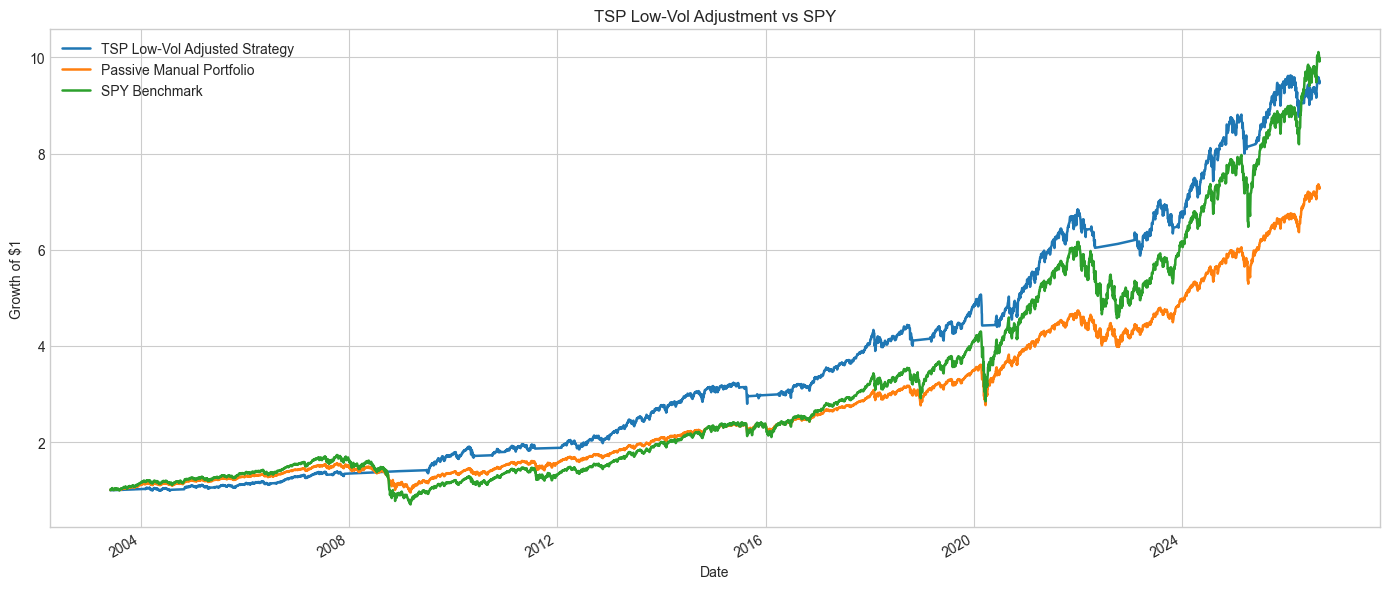

In [144]:
equity = pd.concat(
    [
        strategy_equity.rename('TSP Low-Vol Adjusted Strategy'),
        passive_equity.rename('Passive Manual Portfolio'),
        benchmark_equity.rename(f'{BENCHMARK_TICKER} Benchmark'),
    ],
    axis=1,
).dropna()
ax = equity.plot(figsize=(14, 6), linewidth=1.8, title=f'TSP Low-Vol Adjustment vs {BENCHMARK_TICKER}')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()